# Post-process trip data

## Install and import packages

In [ ]:
#!pip install --upgrade seaborn
!pip install plotly

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.0
    Uninstalling seaborn-0.12.0:
      Successfully uninstalled seaborn-0.12.0
  Using cached plotly-6.3.0-py3-none-any.whl (9.8 MB)
  Using cached narwhals-2.1.2-py3-none-any.whl (392 kB)


In [ ]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

## Data Inspection and Cleaning

### Load Synthetic Data

In [ ]:
# Load trip data
trip_data = pd.read_csv('./Generated_data/EV_generated_data.csv')
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

NameError: name 'pd' is not defined

### Data description

In [ ]:
# Remove duplicates
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of records after removing duplicates: {len(trip_data)}")

NameError: name 'trip_data' is not defined

In [ ]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Records with missing values:\n")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    records_with_nan.head(length)

In [ ]:
# statistics of the dataset for odo, end_odo, soc, end_soc
print("Statistics of the dataset:")
trip_data[['odo', 'end_odo', 'soc', 'end_soc']].describe().T

In [ ]:
# Add km_driven and discharge
trip_data['km_driven'] = trip_data['end_odo'] - trip_data['odo']
trip_data['discharge'] = trip_data['soc'] - trip_data['end_soc']

# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['end_odo'] - trip_data['odo']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

### Identify and remove anomalous records

In [ ]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of useless rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge


In [ ]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [ ]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of anomalous rows: 0
Anomalous rows:
Empty DataFrame
Columns: [odo, end_odo, soc, end_soc, event, charge_mode, duration_minutes, km_driven, discharge, avg_speed]
Index: []


In [ ]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [ ]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['soc'] == trip_data['end_soc']) & (trip_data['end_odo'] == trip_data['odo']) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
if length > 0:
    stationary_records.head(length)

Number of anomalous rows: 0


In [ ]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [ ]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['end_soc'] > trip_data['soc'] + 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
if length > 0:
    anomalous_soc_records.head(length)

In [ ]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

Number of rows removed:                 odo       end_odo        soc    end_soc  event  charge_mode  \
15     14520.734029  13708.656494  48.614630  51.361751      0            0   
22     10024.100863   8788.221300  55.880972  61.891879      0            0   
24     10049.903814   8930.508427  65.310097  70.463157      0            0   
31     15466.576410  14700.105497  59.434412  62.364983      0            0   
32     15157.956891  14940.860910  63.400886  64.465096      0            0   
...             ...           ...        ...        ...    ...          ...   
11863  14760.926030  14398.653170  47.465374  50.880922      0            0   
11865  14799.623467  14390.711879  63.103625  65.672899      0            0   
11918   3461.387579   3306.129057  78.164834  85.470204      0            0   
11930   7402.359801   7325.617289  72.242282  76.293173      0            0   
11937  11884.601592  10890.545443  51.314942  62.293125      0            0   

       duration_minutes    

In [ ]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['end_odo'] < trip_data['odo'])]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anamalous rows: 9505


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed
0,12627.769074,12271.734581,64.351143,62.093434,0,0,45.361559,-356.034492,2.257710,-470.928910
1,12583.637299,12128.996290,75.069862,73.404045,0,0,40.530000,-454.641009,1.665817,-673.043681
2,12445.929464,12035.854804,75.921809,72.989157,0,0,39.436737,-410.074660,2.932651,-623.897455
3,12555.846483,12014.914256,83.020446,79.424545,0,0,44.261844,-540.932227,3.595901,-733.271160
4,12649.971102,12192.068137,80.944202,76.053205,0,0,45.028593,-457.902965,4.890996,-610.149594
...,...,...,...,...,...,...,...,...,...,...
10927,12156.354426,11769.665165,62.983354,58.071254,0,0,38.663127,-386.689261,4.912100,-600.089991
10928,12116.681697,11768.514629,79.247947,76.286897,0,0,41.488802,-348.167068,2.961050,-503.509932
10929,11854.220429,11640.886352,72.799498,59.955250,0,0,77.464560,-213.334077,12.844248,-165.237427
10931,12663.715057,12504.091550,53.621364,42.498832,0,0,66.434174,-159.623507,11.122531,-144.163911


In [ ]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [ ]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
if length > 0:
    anomalous_speed_records.head(length)

maximum speed:  635.7243053630218

 Row with maximum speed:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed
0,9496.165242,9639.593083,67.010125,58.150133,0,0,63.049285,143.427842,8.859992,136.491168
3,11346.797885,11424.286864,61.067229,58.503030,0,0,30.623001,77.488979,2.564200,151.825052
9,10910.877857,11102.283269,77.464707,72.439337,0,0,46.367292,191.405411,5.025370,247.681591
18,8824.755250,9165.171791,86.903841,82.393615,0,0,67.462390,340.416541,4.510226,302.761176
20,9285.546876,9759.113046,46.700519,35.248836,0,0,72.378616,473.566169,11.451682,392.574104
...,...,...,...,...,...,...,...,...,...,...
1402,11136.650855,11371.505956,62.751997,48.384188,0,0,101.375770,234.855101,14.367810,139.000731
1403,11109.198229,11322.017617,81.658351,78.975293,0,0,79.345770,212.819388,2.683058,160.930611
1415,14947.048933,15158.379363,82.201377,74.810106,0,0,69.046284,211.330430,7.391271,183.642408
1420,7746.316495,7856.743887,76.088509,71.398190,0,0,41.947055,110.427392,4.690318,157.952532


In [ ]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [ ]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

if length > 0:
    anomalous_discharge_records.head(length)

Number of anamalous rows: 69


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
12,6295.837975,6296.745266,76.157646,65.351339,0,0,78.271385,0.907291,10.806307,0.695497,0.083959,11.910515
18,11136.774680,11142.532054,76.467130,69.843037,0,0,60.724424,5.757374,6.624092,5.688690,0.869157,1.150541
24,10183.928176,10194.776124,71.252844,53.569977,0,0,123.658065,10.847949,17.682866,5.263522,0.613472,1.630065
30,8285.026258,8285.124454,73.473701,70.822564,0,0,40.540677,0.098196,2.651138,0.145330,0.037039,26.998419
48,13843.338477,13848.964619,64.237004,53.955762,0,0,65.021273,5.626142,10.281241,5.191663,0.547224,1.827405
...,...,...,...,...,...,...,...,...,...,...,...,...
869,14447.992593,14449.874300,53.331396,49.536242,0,0,45.505636,1.881707,3.795154,2.481064,0.495818,2.016868
886,12490.900056,12504.609924,69.488930,52.051064,0,0,121.396818,13.709867,17.437866,6.776059,0.786212,1.271921
903,5352.960082,5353.315657,84.655104,81.431517,0,0,26.899089,0.355575,3.223587,0.793131,0.110304,9.065838
915,9252.282445,9253.257309,75.150083,69.554943,0,0,67.642697,0.974864,5.595140,0.864718,0.174234,5.739406


In [ ]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [ ]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

if length > 0:
    anomalous_discharge_records.head(length)

In [ ]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

## Data Visualization and Comparative Analysis

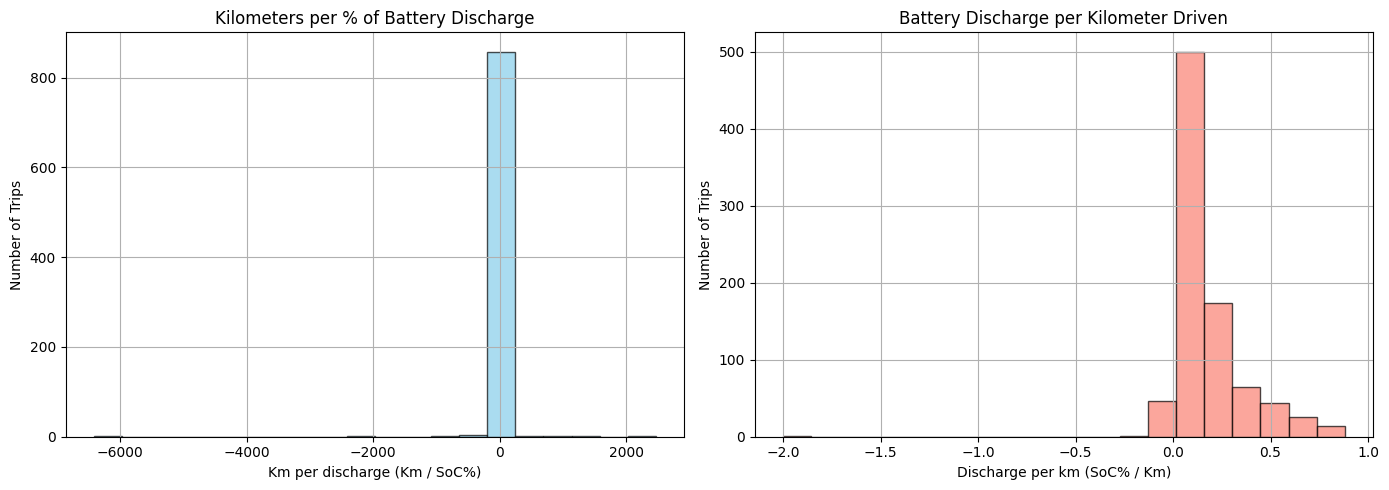

In [114]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [115]:
trip_data.head()

,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,9835.307724,9928.367558,66.567946,61.629488,0,0,61.282781,93.059834,4.938458,91.111890,18.843906,0.053068
1,10870.133306,10884.165925,80.486717,81.486633,0,0,114.214564,14.032619,-0.999916,7.371714,-14.033796,-0.071257
2,8227.788296,8320.000524,70.005348,62.893186,0,0,49.017334,92.212229,7.112162,112.873004,12.965428,0.077128
3,8267.431732,8310.318457,62.391523,60.822610,0,0,30.679363,42.886725,1.568913,83.874084,27.335315,0.036583
4,8144.869210,8188.066887,79.627931,76.738432,0,0,51.684764,43.197678,2.889499,50.147480,14.949884,0.066890


In [ ]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Row with maximum Km/SoC driven:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
445,16303.236735,16431.523952,78.248,78.195987,0,0,85.535438,128.287217,0.052013,89.988818,2466.437082,0.000405


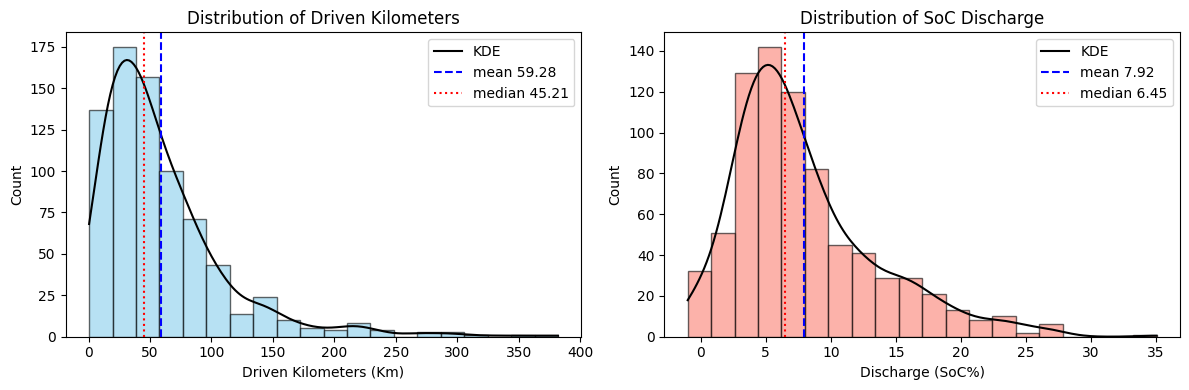

In [119]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

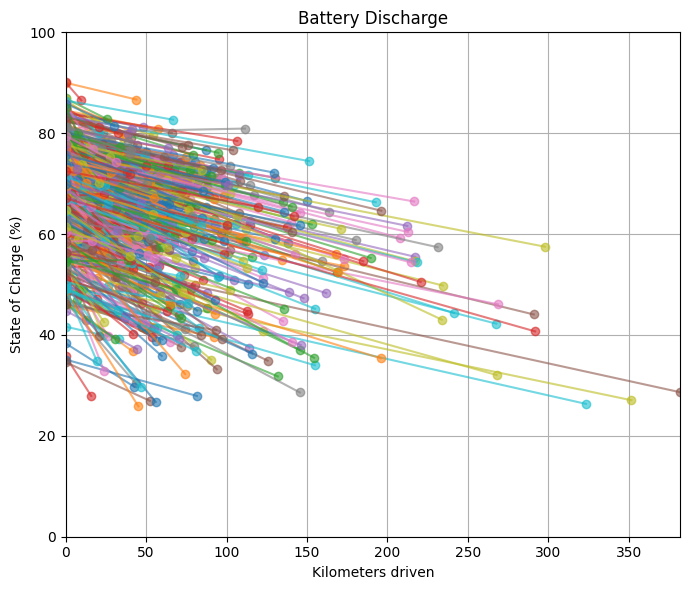

In [120]:
# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [121]:
trip_data['discharge_per_km'].describe()

count    761.000000
mean       0.195224
std        0.192020
min       -2.002338
25%        0.083450
50%        0.133308
75%        0.245531
max        0.880725
Name: discharge_per_km, dtype: float64

## Original dataset

In [ ]:
trip_data_original = pd.read_csv('./datasets/EV_data.csv')
trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          527 non-null    float64
 1   timestamp    527 non-null    object 
 2   end_time     527 non-null    object 
 3   odo          527 non-null    float64
 4   end_odo      527 non-null    float64
 5   soc          527 non-null    float64
 6   end_soc      527 non-null    float64
 7   event        527 non-null    object 
 8   charge_mode  527 non-null    object 
dtypes: float64(5), object(4)
memory usage: 37.2+ KB


In [123]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 527
📊 Statistics on driven km:
 count    527.000000
mean      41.088105
std       50.508957
min        0.000000
25%        8.171872
50%       15.937500
75%       61.273435
max      378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    527.00000
mean       7.90797
std        9.98188
min       -0.40000
25%        1.20000
50%        3.10000
75%       11.75000
max       74.60000
Name: discharge, dtype: float64


In [124]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [127]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 6


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446


In [128]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     521 non-null    float64
 1   timestamp               521 non-null    object 
 2   end_time                521 non-null    object 
 3   odo                     521 non-null    float64
 4   end_odo                 521 non-null    float64
 5   soc                     521 non-null    float64
 6   end_soc                 521 non-null    float64
 7   event                   521 non-null    object 
 8   charge_mode             521 non-null    object 
 9   km_driven               521 non-null    float64
 10  discharge               521 non-null    float64
 11  km_per_perc_of_battery  521 non-null    float64
 12  discharge_per_km        521 non-null    float64
dtypes: float64(9), object(4)
memory usage: 53.0+ KB


In [129]:
trip_data_original['discharge_per_km'].describe()

count    521.000000
mean       0.170649
std        0.086673
min       -0.474074
25%        0.146958
50%        0.182206
75%        0.203904
max        0.752941
Name: discharge_per_km, dtype: float64